# asymptotics — Step-by-Step Perturbation Expansion

`begin_expansion()` gives you full control over the perturbation process — inspect equations at each order, let SymPy solve when it can, and provide solutions manually when it can't (from Mathematica, Maple, or by hand).

```python
sol = eq.begin_expansion(order=N)   # sets up hierarchy, solves nothing
sol[k].ode                          # see the order-k equation
sol[k].solve()                      # try SymPy
sol[k].set_solution(expr)           # or provide manually
sol.solve_all()                     # try all remaining

# Once all solved — full standard API
sol.composite
sol.show()
sol.eval(eps=0.1, at=t_vals)
sol.compare_numeric(eps=0.1)
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sympy import *
from IPython.display import display, Math, HTML
from asymptotics import ODE

# t_sym = symbols('t')

---
## Example 1 — Fully automatic (SymPy handles everything)

The Duffing oscillator:
$$u'' + u + \varepsilon u^3 = 0, \qquad u(0)=1,\quad u'(0)=0$$

Here `begin_expansion` + `solve_all()` is equivalent to `expand_regular()`, but you see every step.

In [2]:
eq = ODE(
    "u'' + u + eps*u**3",
    small_param = "eps",
    conditions  = ["u(0) = 1", "u'(0) = 0"],
)

sol = eq.begin_expansion(order=2)

# See all equations before solving anything
sol.show()

  ℹ️  dependent = 'u' (inferred from conditions), independent = 't' (inferred from equation)
     To override: ODE(..., dependent='u', independent='t')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [3]:
# Inspect order 0 equation
sol[0].ode

<IPython.core.display.Math object>

O(ε⁰) — symbolic:
  Eq(u_0(t) + Derivative(u_0(t), (t, 2)), 0)

In [4]:
# Solve order 0
sol[0].solve()

  ✓  Order 0 solved: u_0 = cos(t)


True

In [5]:
# Now sol[1].ode shows BOTH — symbolic AND with u0=cos(t) substituted
sol[1].ode

<IPython.core.display.Math object>

<IPython.core.display.Math object>

O(ε¹) — symbolic:
  Eq(u_0(t)**3 + u_1(t) + Derivative(u_1(t), (t, 2)), 0)

O(ε¹) — substituted:
  Eq(u_1(t) + 3*cos(t)/4 + cos(3*t)/4 + Derivative(u_1(t), (t, 2)), 0)

In [6]:
# Solve remaining orders
sol[1].solve()
sol[2].solve()

# Full hierarchy
sol.show()

  ✓  Order 1 solved: u_1 = -3*t*sin(t)/8 - cos(t)/32 + cos(3*t)/32
  ✓  Order 2 solved: u_2 = 3*t*sin(t)/32 - 9*t*sin(3*t)/256 + (23/1024 - 9*t**2/128)*cos(t) - 3*cos(3*t)/128 + cos(5*t)/1024

  ✓  All orders solved. composite is now available.



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

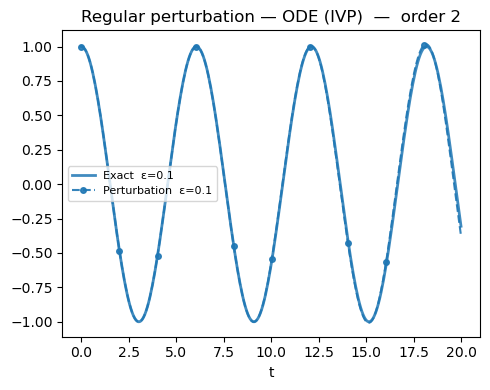

In [7]:
# Standard API now available
t_vals = np.linspace(0, 20, 400)
sol.compare_numeric(eps=0.1, plot_range=[0, 20]);

---
## Example 2 — Mixed: user provides O(1), SymPy handles rest

Same Duffing equation, but we deliberately provide the O(1) solution manually
to demonstrate `set_solution()`. This is the workflow when SymPy fails at O(1).

In [8]:
eq2 = ODE(
    "u'' + u + eps*u**3",
    small_param = "eps",
    conditions  = ["u(0) = 1", "u'(0) = 0"],
)

sol2 = eq2.begin_expansion(order=2)

# Inspect O(1) equation
print("O(1) equation:", sol2[0].ode.symbolic)
print()

# Provide solution manually (e.g. from Mathematica/Maple or by hand)
t = Symbol('t')
sol2[0].set_solution(cos(t))   # u0(t) = cos(t)

# SymPy handles O(eps) automatically with u0 substituted
sol2[1].solve()
sol2[2].solve()

sol2.show()

  ℹ️  dependent = 'u' (inferred from conditions), independent = 't' (inferred from equation)
     To override: ODE(..., dependent='u', independent='t')
O(1) equation: Eq(u_0(t) + Derivative(u_0(t), (t, 2)), 0)

  ✓  Order 0 set manually: u_0 = cos(t)
  ✓  Order 1 solved: u_1 = -3*t*sin(t)/8 - cos(t)/32 + cos(3*t)/32
  ✓  Order 2 solved: u_2 = 3*t*sin(t)/32 - 9*t*sin(3*t)/256 + (23/1024 - 9*t**2/128)*cos(t) - 3*cos(3*t)/128 + cos(5*t)/1024

  ✓  All orders solved. composite is now available.



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

---
## Example 3 — 3rd order ODE with limit BC

A 3rd order ODE with a regularity condition at a singular point:
$$t\,u''' + u'' + \varepsilon u^2 = 0$$
with $u(1)=1$, $u'(1)=0$, $\lim_{t\to 0}\sqrt{t}\,u'' = 0$.

In [9]:
eq3 = ODE(
    "t*u''' + u'' + eps*u**2",
    small_param = "eps",
    independent = "t",
    conditions  = [
        "u(1) = 1",
        "u'(1) = 0",
        "lim(sqrt(t)*u'', t, 0) = 0",   # regularity at singular point
    ],
)

print("ODE order:", eq3.ode_order)
print("Conditions:")
for c in eq3.conditions:
    print(" ", c)

sol3 = eq3.begin_expansion(order=1)
sol3.show()

  ℹ️  dependent = 'u' (inferred from conditions), independent = 't' (supplied)
     To override: ODE(..., dependent='u', independent='t')
ODE order: 3
Conditions:
  u(1) = 1
  u'(1) = 0
  lim(sqrt(t)*u'', t, 0) = 0


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [10]:
# Solve — limit condition eliminates the log singularity automatically
sol3.solve_all()
sol3.show()

  ✓  Order 0 solved: u_0 = 1
  ✓  Order 1 solved: u_1 = -t**2/2 + t - 1/2

  ✓  All orders solved. composite is now available.


  ✓  All orders solved. composite is now available.



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [11]:
# Evaluate and compare
sol3.compare_numeric(eps=0.1, plot_range=[0, 1]);

NotImplementedError: 

  compare_numeric does not support limit boundary conditions:
    lim(sqrt(t)*u'', t, 0) = 0

  Singular BVPs require specialized numerical treatment
  (e.g. Frobenius-type methods or Mathematica's NDSolve).

  You can still use the symbolic expansion:
    sol.show()
    sol.eval(eps=0.1, at=t_vals)
    sol.to_latex()


In [54]:
sol3.eval(eps=0.1,at = np.linspace(0,1,10))

array([0.95      , 0.96049383, 0.96975309, 0.97777778, 0.9845679 ,
       0.99012346, 0.99444444, 0.99753086, 0.99938272, 1.        ])

In [55]:
import numpy as np
from scipy.integrate import solve_bvp

def odes(t, y):
    # u''' = (-u'' - eps*u^2) / t
    return np.vstack((y[1], y[2], (-y[2] - epsilon * y[0]**2) / t))

def boundary_conditions(ya, yb):
    # ya is at t=delta, yb is at t=1
    # Condition 1 & 2: u(1)=1, u'(1)=0
    # Condition 3: u''(0) + eps*u(0)^2 = 0 (Derived from regularity)
    return np.array([yb[0] - 1, yb[1] - 0, ya[2] + epsilon * ya[0]**2])

epsilon = 0.1
t_steps = np.linspace(1e-5, 1, 100) # Avoid t=0
y_guess = np.zeros((3, t_steps.size))
y_guess[0] = 1 # Initial guess based on perturbation solution

res = solve_bvp(odes, boundary_conditions, t_steps, y_guess)

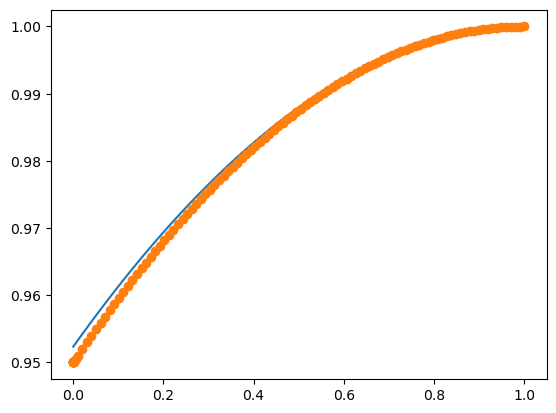

In [56]:
plt.plot(res.x,res.y[0])
plt.plot(res.x,sol3.eval(eps=0.1,at = res.x),'-o')

---
## Example 4 — The Paper ODE

A 4th order similarity ODE from the paper, where $\varepsilon = 1/Re$ is small (large Reynolds number):

$$\varepsilon\left[\eta F'''' + \alpha(\eta F''' + 2F'') + 2F'''\right] + \frac{1}{2}(F F''' - F'F'') = 0$$

Boundary conditions:
- $F(0) = 0$
- $F(1/2) = 1$  
- $F'(1/2) = 0$
- $\lim_{\eta\to 0}\sqrt{2\eta}\,F'' = 0$ (regularity at singular point)

**Note:** The O(1) equation $FF''' - F'F'' = 0$ is nonlinear — SymPy cannot solve it in general.
We provide the known solution $F_0 = 4\eta(1-\eta)$.

In [13]:
eta_sym = Symbol('eta', positive=True)

eq4 = ODE(
    "eps*(eta*F'''' + alpha*(eta*F''' + 2*F'') + 2*F''') + (F*F''' - F'*F'')/2",
    small_param = "eps",
    independent = "eta",
    conditions  = [
        "F(0) = 0",
        "F(1/2) = 1",
        "F'(1/2) = 0",
        "lim(sqrt(2*eta)*F'', eta, 0) = 0",
    ],
)

print("ODE order:", eq4.ode_order)
print("Parameters detected:", eq4.params)

sol4 = eq4.begin_expansion(order=1)
sol4.show()

  ℹ️  dependent = 'F' (inferred from conditions), independent = 'eta' (supplied)
     To override: ODE(..., dependent='F', independent='eta')
  ⚠️  symbolic parameters detected: {'alpha'}
     Provide values at eval/compare time:
     sol.eval(eps=0.1, at=t_vals, params={'alpha': value})
ODE order: 4
Parameters detected: {'alpha'}


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [14]:
# O(1): F*F''' - F'*F'' = 0 — SymPy can't solve this nonlinear ODE
# Try SymPy first
success = sol4[0].solve()

if not success:
    print()
    print("SymPy cannot solve the nonlinear O(1) equation.")
    print("Known analytical solution: F₀ = 4η(1-η)")
    print("Verify: F₀(0)=0 ✓, F₀(1/2)=1 ✓, F₀'(1/2)=0 ✓, lim√(2η)F₀''→0 ✓")
    print()

    # Verify manually
    F0 = 4*eta_sym*(1 - eta_sym)
    print("F₀(0)   =", F0.subs(eta_sym, 0))
    print("F₀(1/2) =", F0.subs(eta_sym, Rational(1,2)))
    print("F₀'(1/2)=", diff(F0, eta_sym).subs(eta_sym, Rational(1,2)))
    
    expr_lim = sqrt(2*eta_sym) * diff(F0, eta_sym, 2)
    print("lim√(2η)F₀'' as η→0:", limit(expr_lim, eta_sym, 0, '+'))


  ✗  Could not solve O(ε⁰) equation automatically:
     Eq(F_0(eta)*Derivative(F_0(eta), (eta, 3))/2 - Derivative(F_0(eta), eta)*Derivative(F_0(eta), (eta, 2))/2, 0)

  Provide the solution manually:
     sol[0].set_solution(your_expr)
  or solve in Mathematica/Maple and paste the result.


SymPy cannot solve the nonlinear O(1) equation.
Known analytical solution: F₀ = 4η(1-η)
Verify: F₀(0)=0 ✓, F₀(1/2)=1 ✓, F₀'(1/2)=0 ✓, lim√(2η)F₀''→0 ✓

F₀(0)   = 0
F₀(1/2) = 1
F₀'(1/2)= 0
lim√(2η)F₀'' as η→0: 0


In [15]:
# Provide the O(1) solution manually
sol4[0].set_solution(4*eta_sym*(1 - eta_sym))

# Show O(1) equation with substitution for O(eps)
sol4.show()

  ✓  Order 0 set manually: F_0 = 4*eta*(1 - eta)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [16]:
# Try to solve O(eps) with SymPy
# The O(eps) equation is linear in F1 but variable-coefficient
# with alpha as a symbolic parameter
print("Attempting to solve O(ε) with alpha as symbolic parameter...")
success1 = sol4[1].solve()

if not success1:
    print()
    print("SymPy cannot solve the variable-coefficient O(ε) equation symbolically.")
    print("Options:")
    print("  1. Fix alpha to a specific value and retry")
    print("  2. Solve in Mathematica/Maple and paste result")
    print("  3. Use numerical perturbation")

Attempting to solve O(ε) with alpha as symbolic parameter...

  ✗  Could not solve O(ε¹) equation automatically:
     Eq(alpha*eta*Derivative(-4*eta**2 + 4*eta, (eta, 3)) + 2*alpha*Derivative(-4*eta**2 + 4*eta, (eta, 2)) + eta*Derivative(-4*eta**2 + 4*eta, (eta, 4)) - 2*eta**2*Derivative(F_1(eta), (eta, 3)) + 2*eta*Derivative(F_1(eta), (eta, 3)) + F_1(eta)*Derivative(-4*eta**2 + 4*eta, (eta, 3))/2 - Derivative(-4*eta**2 + 4*eta, eta)*Derivative(F_1(eta), (eta, 2))/2 - Derivative(-4*eta**2 + 4*eta, (eta, 2))*Derivative(F_1(eta), eta)/2 + 2*Derivative(-4*eta**2 + 4*eta, (eta, 3)), 0)

  Provide the solution manually:
     sol[1].set_solution(your_expr)
  or solve in Mathematica/Maple and paste the result.


SymPy cannot solve the variable-coefficient O(ε) equation symbolically.
Options:
  1. Fix alpha to a specific value and retry
  2. Solve in Mathematica/Maple and paste result
  3. Use numerical perturbation


In [17]:
# Try with alpha = 0 (simplest case)
print("Trying with alpha = 0...")

eq4b = ODE(
    "eps*(eta*F'''' + 2*F''') + (F*F''' - F'*F'')/2",
    small_param = "eps",
    independent = "eta",
    conditions  = [
        "F(0) = 0",
        "F(1/2) = 1",
        "F'(1/2) = 0",
        "lim(sqrt(2*eta)*F'', eta, 0) = 0",
    ],
)

sol4b = eq4b.begin_expansion(order=1)

# O(1): same nonlinear equation — provide solution
sol4b[0].set_solution(4*eta_sym*(1 - eta_sym))

# O(eps): now purely linear with eta as coefficient — try SymPy
sol4b[1].solve()

Trying with alpha = 0...
  ℹ️  dependent = 'F' (inferred from conditions), independent = 'eta' (supplied)
     To override: ODE(..., dependent='F', independent='eta')
  ✓  Order 0 set manually: F_0 = 4*eta*(1 - eta)

  ✗  Could not solve O(ε¹) equation automatically:
     Eq(eta*Derivative(-4*eta**2 + 4*eta, (eta, 4)) - 2*eta**2*Derivative(F_1(eta), (eta, 3)) + 2*eta*Derivative(F_1(eta), (eta, 3)) + F_1(eta)*Derivative(-4*eta**2 + 4*eta, (eta, 3))/2 - Derivative(-4*eta**2 + 4*eta, eta)*Derivative(F_1(eta), (eta, 2))/2 - Derivative(-4*eta**2 + 4*eta, (eta, 2))*Derivative(F_1(eta), eta)/2 + 2*Derivative(-4*eta**2 + 4*eta, (eta, 3)), 0)

  Provide the solution manually:
     sol[1].set_solution(your_expr)
  or solve in Mathematica/Maple and paste the result.



False

In [18]:
# Show the full result
sol4b.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [19]:
# Plot the perturbation expansion vs numerical solution
from scipy.integrate import solve_bvp

eps_val  = 0.1
eta_vals = np.linspace(0, 0.5, 300)
eps_sym  = sol4b.small_param

# Perturbation composite
comp_fn = lambdify(eta_sym, sol4b.composite.subs(eps_sym, eps_val), 'numpy')
F_pert  = np.real(np.array([complex(comp_fn(e)) for e in eta_vals]))

# Numerical solution (full nonlinear BVP)
def rhs_bvp(eta, y):
    # y = [F, F', F'', F''']
    # eps*F'''' + 2*eps*F''' + (F*F''' - F'*F'')/2 = 0
    # F'''' = -(2*F''' + (F*F''' - F'*F'')/(2*eps)) / 1
    F, Fp, Fpp, Fppp = y
    Fpppp = -(2*Fppp + (F*Fppp - Fp*Fpp)/(2*eps_val))
    return [Fp, Fpp, Fppp, Fpppp]

def bc(ya, yb):
    return [
        ya[0],           # F(0) = 0
        yb[0] - 1,       # F(1/2) = 1
        yb[1],           # F'(1/2) = 0
        ya[2],           # F''(0) regularity (approx)
    ]

# Initial guess from perturbation
eta_grid = np.linspace(0, 0.5, 50)
y0       = np.zeros((4, len(eta_grid)))
y0[0]    = np.array([float(comp_fn(e)) for e in eta_grid])

try:
    sol_num = solve_bvp(rhs_bvp, bc, eta_grid, y0, tol=1e-6, max_nodes=5000)
    F_num   = sol_num.sol(eta_vals)[0]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(eta_vals, F_num,  'k-',   lw=2,   label='Numerical (exact)', alpha=0.9)
    axes[0].plot(eta_vals, F_pert, 'ro--', lw=1.5, ms=4, markevery=20,
                 label=f'Perturbation (order 1)')
    axes[0].set_xlabel(r'$\eta$'); axes[0].set_ylabel(r'$F(\eta)$')
    axes[0].set_title(f'Paper ODE (α=0, ε={eps_val})')
    axes[0].legend()
    
    axes[1].semilogy(eta_vals, np.abs(F_pert - F_num) + 1e-16, 'b-')
    axes[1].set_xlabel(r'$\eta$'); axes[1].set_title('Absolute error')
    plt.tight_layout()
    plt.show()
    print(f'Max error: {np.max(np.abs(F_pert - F_num)):.2e}')
except Exception as e:
    print('Numerical solve failed:', e)
    # Just plot perturbation
    plt.plot(eta_vals, F_pert)
    plt.xlabel(r'$\eta$'); plt.ylabel(r'$F(\eta)$')
    plt.title('Perturbation solution (α=0)')
    plt.show()

AttributeError: 'NoneType' object has no attribute 'subs'

---
## API Reference

```python
sol = eq.begin_expansion(order=N)

# Before solving
sol.show()                        # see all equations (solutions pending)
sol[k].ode                        # order-k equation:
                                  #   symbolic only if lower orders unsolved
                                  #   both forms if lower orders solved
sol[k].is_solved                  # bool
sol.n_solved                      # int — how many solved so far
sol.n_pending                     # int — how many remain

# Solving
sol[k].solve()                    # try SymPy, fail gracefully
sol[k].set_solution(expr)         # provide manually
sol.solve_all()                   # try all remaining

# After solving
sol[k].ode                        # equation (with substituted form)
sol[k].particular_solution        # solution at order k
sol[k].general_solution           # with free constants
sol[k].secular                    # True if secular terms detected

# Full standard API (once all solved)
sol.composite
sol.show()
sol.to_latex()
sol.eval(eps=0.1, at=t_vals)
sol.compare_numeric(eps=0.1)
```

### Limit boundary conditions

```python
conditions = [
    "u(0) = 0",
    "u(1) = 1",
    "lim(sqrt(t)*u'', t, 0) = 0",   # regularity at singular point
]
```

### Higher-order ODEs

```python
eq = ODE(
    "u'''' + u'' + eps*u",          # 4th order
    small_param = "eps",
    conditions  = ["u(0)=0", "u'(0)=1", "u''(0)=0", "u'''(0)=0"],
)
```